In [1]:
from __future__ import print_function
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

1. Adding alayer after GAP
2. Reducing params under 8k

In [2]:
# CUDA?
cuda = torch.cuda.is_available()
print("CUDA Available?", cuda)

CUDA Available? True


In [3]:
# Train data transformations
train_transforms = transforms.Compose([
    transforms.RandomApply([transforms.CenterCrop(22), ], p=0.1),
    transforms.Resize((28, 28)),
    transforms.RandomRotation((-15.0, 15.0), fill=(1,)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    ])

# Test data transformations
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
    ])

In [4]:
train_data = datasets.MNIST('../data', train=True, download=True, transform=train_transforms)
test_data = datasets.MNIST('../data', train=False, download=True, transform=test_transforms)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 503kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.1MB/s]


In [5]:
# Slightly larger batch helps convergence speed in 1 epoch
train_loader = torch.utils.data.DataLoader(train_data, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_data,  batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

In [6]:
batch_size = 64

kwargs = {'batch_size': batch_size, 'shuffle': True, 'num_workers': 2, 'pin_memory': True}

test_loader = torch.utils.data.DataLoader(test_data, **kwargs)
train_loader = torch.utils.data.DataLoader(train_data, **kwargs)

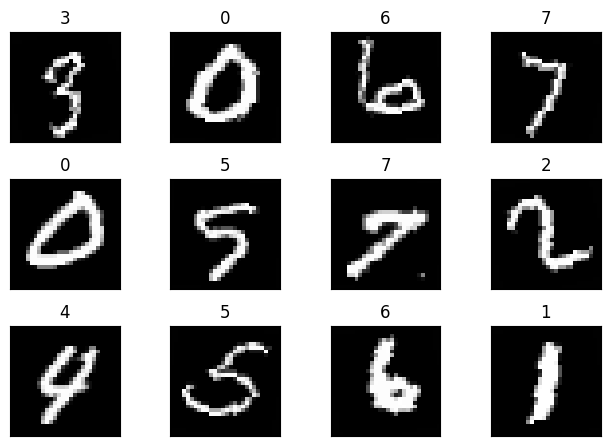

In [7]:
import matplotlib.pyplot as plt

batch_data, batch_label = next(iter(train_loader))

fig = plt.figure()

for i in range(12):
  plt.subplot(3,4,i+1)
  plt.tight_layout()
  plt.imshow(batch_data[i].squeeze(0), cmap='gray')
  plt.title(batch_label[i].item())
  plt.xticks([])
  plt.yticks([])

In [10]:
# Data to plot accuracy and loss graphs
train_losses = []
test_losses = []
train_acc = []
test_acc = []

test_incorrect_pred = {'images': [], 'ground_truths': [], 'predicted_vals': []}

In [11]:
from tqdm import tqdm

def GetCorrectPredCount(pPrediction, pLabels):
    return pPrediction.argmax(dim=1).eq(pLabels).sum().item()

def train(model, device, train_loader, optimizer, criterion, scheduler=None, grad_clip=None):
    """
    Train for one epoch.
    - scheduler: pass your OneCycleLR here; will be stepped *per batch*
    - grad_clip: (float or None) max norm for gradient clipping (e.g., 1.0)
    """
    model.train()
    pbar = tqdm(train_loader)

    train_loss_sum = 0.0
    correct = 0
    processed = 0

    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad(set_to_none=True)

        # Forward
        logits = model(data)
        loss = criterion(logits, target)

        # Backward
        loss.backward()

        # (Optional) gradient clipping for stability at high max_lr
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        # OneCycleLR: *step per batch*
        if scheduler is not None:
            scheduler.step()

        # Book-keeping
        train_loss_sum += loss.item() * data.size(0)  # sum over samples
        correct += GetCorrectPredCount(logits, target)
        processed += data.size(0)

        # Show current LR & running stats
        curr_lr = optimizer.param_groups[0]["lr"]
        pbar.set_description(
            f"Train: loss={train_loss_sum/processed:.4f} "
            f"acc={100.0*correct/processed:.2f}% lr={curr_lr:.5f}"
        )

    # Return epoch averages (useful if you want to log outside)
    epoch_loss = train_loss_sum / processed
    epoch_acc = 100.0 * correct / processed
    return epoch_loss, epoch_acc



def test(model, device, test_loader, criterion):
    model.eval()
    test_loss_sum = 0.0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            # sum batch loss over samples for true average at the end
            test_loss_sum += criterion(output, target).item() * target.size(0)
            correct += GetCorrectPredCount(output, target)

    avg_loss = test_loss_sum / len(test_loader.dataset)
    avg_acc = 100.0 * correct / len(test_loader.dataset)

    print(f"Test set: Average loss: {avg_loss:.4f}, "
          f"Accuracy: {correct}/{len(test_loader.dataset)} ({avg_acc:.2f}%)\n")

    return avg_loss, avg_acc

In [12]:
dropout_value = 0.025 # Slightly decreased dropout
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(8),
            nn.Dropout(dropout_value)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(8, 8, 3, padding=0),
            nn.ReLU(),
            nn.BatchNorm2d(8),
            nn.Dropout(dropout_value)
        )
        # TRANSITION BLOCK 1
        self.conv3 = nn.Sequential(
            nn.Conv2d(8, 8, 1, padding=0),
            nn.ReLU(),
            nn.BatchNorm2d(8),
            nn.Dropout(dropout_value)
        ) # output_size = 24
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv4 = nn.Sequential(
            nn.Conv2d(8, 16, 3, padding=0),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.Dropout(dropout_value)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(16, 16, 3, padding=0),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.Dropout(dropout_value)
        )
        # TRANSITION BLOCK 2
        self.conv6 = nn.Sequential(
            nn.Conv2d(16, 16, 1, padding=0)
        ) # output_size = 24
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv7 = nn.Sequential(
            nn.Conv2d(16, 12, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(12),

            nn.Dropout(dropout_value)
        )

        self.conv8 = nn.Sequential(
            nn.Conv2d(12, 10, 3, padding=0),
            nn.ReLU(),
            nn.BatchNorm2d(10),

            nn.Dropout(dropout_value)
        )


        self.gap = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1))

        )
        self.conv10 = nn.Sequential(
            nn.Conv2d(10, 10, 1)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.pool1(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.pool2(x)
        x = self.conv7(x)
        x = self.conv8(x)
        x = self.gap(x)
        x = self.conv10(x)
        x = x.view(-1, 10)
        # return F.log_softmax(x, dim=-1)
        return x

In [14]:
!pip install torchsummary
from torchsummary import summary
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
model = Net().to(device)
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 28, 28]              80
              ReLU-2            [-1, 8, 28, 28]               0
       BatchNorm2d-3            [-1, 8, 28, 28]              16
           Dropout-4            [-1, 8, 28, 28]               0
            Conv2d-5            [-1, 8, 26, 26]             584
              ReLU-6            [-1, 8, 26, 26]               0
       BatchNorm2d-7            [-1, 8, 26, 26]              16
           Dropout-8            [-1, 8, 26, 26]               0
            Conv2d-9            [-1, 8, 26, 26]              72
             ReLU-10            [-1, 8, 26, 26]               0
      BatchNorm2d-11            [-1, 8, 26, 26]              16
          Dropout-12            [-1, 8, 26, 26]               0
        MaxPool2d-13            [-1, 8, 13, 13]               0
           Conv2d-14           [-1, 16,

In [13]:
model = Net().to(device)
base_lr = 0.001 # Adjusted base_lr for Adam
epochs = 16
steps_per_epoch = len(train_loader)
# Changed optimizer to Adam
optimizer = optim.Adam(model.parameters(), lr=base_lr)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01, # Adjusted max_lr for Adam
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.2,
    anneal_strategy="cos",
    div_factor=10.0, # Adjusted div_factor for Adam
    final_div_factor=100.0, # Adjusted final_div_factor for Adam
    # Removed momentum parameters as they are not used in Adam
)


criterion = nn.CrossEntropyLoss(reduction="mean", label_smoothing=0.0)

# Continue training from where it stopped or start fresh if needed.
# Assuming the model and optimizer state are preserved from the previous run.
# If you want to start training from scratch, re-initialize model and optimizer before this loop.
for epoch in range(1, epochs + 1):
    print(f"Epoch {epoch}")
    tr_loss, tr_acc = train(model, device, train_loader, optimizer, criterion, scheduler=scheduler, grad_clip=None)
    te_loss, te_acc = test(model, device, test_loader, criterion)

Epoch 1


Train: loss=0.5158 acc=87.82% lr=0.00300: 100%|██████████| 938/938 [00:25<00:00, 37.35it/s]


Test set: Average loss: 0.0782, Accuracy: 9781/10000 (97.81%)

Epoch 2


Train: loss=0.1149 acc=96.51% lr=0.00722: 100%|██████████| 938/938 [00:24<00:00, 38.67it/s]


Test set: Average loss: 0.0825, Accuracy: 9783/10000 (97.83%)

Epoch 3


...

Test set: Average loss: 0.0166, Accuracy: 9950/10000 (99.50%)

Epoch 15


Train: loss=0.0287 acc=99.09% lr=0.00016: 100%|██████████| 938/938 [00:24<00:00, 38.77it/s]


Test set: Average loss: 0.0164, Accuracy: 9954/10000 (99.54%)

Epoch 16


Train: loss=0.0273 acc=99.14% lr=0.00001: 100%|██████████| 938/938 [00:24<00:00, 38.50it/s]


Test set: Average loss: 0.0163, Accuracy: 9951/10000 (99.51%)

